## Figure 2 and Table 1: SST Variance Decomposition

**Purpose:** Generate Figure 2 and Table 1 of the paper.

**Description:**
Figure 2 shows spatial maps of (a) mean SST and (b-e) SST standard deviation in [◦C] for (b) total, (c) interannual, (d) annual, (e) semi-annual and (f) intraseasonal frequency bands, calculated from satellite observations over the Indonesian seas and the surrounding ocean basins. (g) The zonal distribution of the SST variance, averaged between the latitudes of 0-10◦S. White boxes in (b) represent the southeastern Indian Ocean, Indonesian seas, and western Pacific Ocean regions used for computing averaged SST standard deviation values shown in Table 1. The blue shading in (g) represents the zonal extent of the Indonesian seas.

**Inputs:**
- `sst_variance_REMSS-MWIR.nc` — power spectral density of SST from REMSS MW+IR dataset
- `sst_mean_REMSS-MWIR.nc`     — mean SST

In [1]:
import xarray as xr 
import numpy as np 
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.patches import Rectangle
from shapely.geometry import LineString
from shapely.ops import unary_union
import regionmask
from shapely.geometry import Polygon 
from shapely.ops import unary_union
import warnings
import logging

In [2]:
import os
os.chdir('/g/data/er50/sb4233/Scripts/Indonesian-seas-SST-variability_JGR-Oceans/') # set the path to working directory

In [3]:
warnings.filterwarnings('ignore')
mpl.rcParams['text.latex.preamble'] = r'\usepackage[utf8]{inputenc}'
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
rcParams.update({
    'text.usetex': True,            
    'font.family': 'Palatino Latino',         
    'font.serif': ['Palatino Latino'],  
    'text.latex.preamble': r'\usepackage{amsmath}'  
})

## Datasets

In [4]:
sst_var  = xr.open_dataset('./data/sst_variance_REMSS-MWIR.nc')
sst_mean = xr.open_dataset('./data/sst_mean_REMSS-MWIR.nc')

## Bounding boxes for Indonesian seas and surrounding Indian & Pacific Oceans

In [5]:
# Indonesian seas polygon

polygon1 = [
    (113, -9),  # bottom-left
    (113,   0),  # top-left
    (135,   0),  # top-right
    (135, -9),  # bottom-right
]

polygon2 = [
    (117, 0),   # bottom-left
    (117,  6),  # top-left
    (127,  6),  # top-right
    (127, 0),   # bottom-right
]
poly1 = Polygon(polygon1) 
poly2 = Polygon(polygon2)
merged_poly = unary_union([poly1, poly2])
merged_coords = list(merged_poly.exterior.coords)
regions = regionmask.Regions( outlines=[merged_coords], names=["CombinedRegion"], abbrevs=["CR"], numbers=[0] )
region1 = regionmask.Regions(outlines=[polygon1])
region2 = regionmask.Regions(outlines=[polygon2])
mask1 = region1.mask(sst_var.lon, sst_var.lat, wrap_lon=False)
mask2 = region2.mask(sst_var.lon, sst_var.lat, wrap_lon=False)

# Indian and Pacific Oceans

IO_lon_range = slice(77, 97)
IO_lat_range = slice(-15,-5)
PO_lon_range = slice(145,165)
PO_lat_range = slice(-2,8)

# Mean SST and bandwise SST variability

In [6]:
mean_sst = sst_mean.analysed_sst

In [7]:
def band_power(psd, freqs, fmin, fmax, aggregate="sum"):
    """
    Band-integrated (or averaged) variance contribution.
    - psd: (..., F)
    - freqs: (F,)
    - fmin, fmax: band edges (inclusive)
    - aggregate: "sum" -> integrates power (variance in that band)
                 "mean"-> averages PSD over band
    """
    sel = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(sel):
        raise ValueError("No frequency bins inside requested band.")
    df = np.diff(freqs).mean() if len(freqs) > 1 else np.nan
    band_psd = psd[..., sel]
    if aggregate == "sum":
        # Integrate PSD over band to get variance contribution
        band_est = np.sum(band_psd, axis=-1) * df
    elif aggregate == "mean":
        band_est = np.mean(band_psd, axis=-1)
    else:
        raise ValueError("aggregate must be 'sum' or 'mean'")
    return band_est


def band_sd_from_ds(power_spectrum, fmin, fmax):
    """Band SD (degC) from a power_spectrum xr.Dataset created earlier."""
    psd    = power_spectrum["PSD"].values 
    freqs  = power_spectrum["frequency"].values 
    # Get band variance
    band_var = band_power(psd, freqs, fmin, fmax, aggregate="sum")
    # Move to SD (degC)
    band_sd = np.sqrt(band_var)
    lat_name, lon_name = 'lat', 'lon'
    coords = {lat_name: power_spectrum[lat_name], lon_name: power_spectrum[lon_name]}
    sd_da = xr.DataArray(band_sd, dims=(lat_name, lon_name), coords=coords)
    sd_da.attrs.update(units="degC", long_name="Band SD (sqrt of band variance)")
    return sd_da

In [8]:
# Bands (cycles/day)
annual      = (1/400, 1/270)        # 270–400 d  (annual ~365 d)
semiannual  = (1/269, 1/120)        # 120–269 d  (semi-annual ~180 d)
seasonal    = (1/400, 1/120)        # 120–400 d
intra       = (1/119, 1/21)         # 21–119 d
inter       = (0.0,   1/401)        # >401 d
total       = (0.0, sst_var['frequency'].max().item())

annual_sd     = band_sd_from_ds(sst_var, *annual)
semiannual_sd = band_sd_from_ds(sst_var, *semiannual)
seasonal_sd   = band_sd_from_ds(sst_var, *seasonal)
intra_sd      = band_sd_from_ds(sst_var, *intra)
inter_sd      = band_sd_from_ds(sst_var, *inter)
total_sd      = band_sd_from_ds(sst_var, *total)

annual_sd     = annual_sd.where(annual_sd != 0)
semiannual_sd = semiannual_sd.where(semiannual_sd != 0)
seasonal_sd   = seasonal_sd.where(seasonal_sd != 0)
intra_sd      = intra_sd.where(intra_sd != 0)
inter_sd      = inter_sd.where(inter_sd != 0)
total_sd      = total_sd.where(total_sd != 0)

## Figure 2:

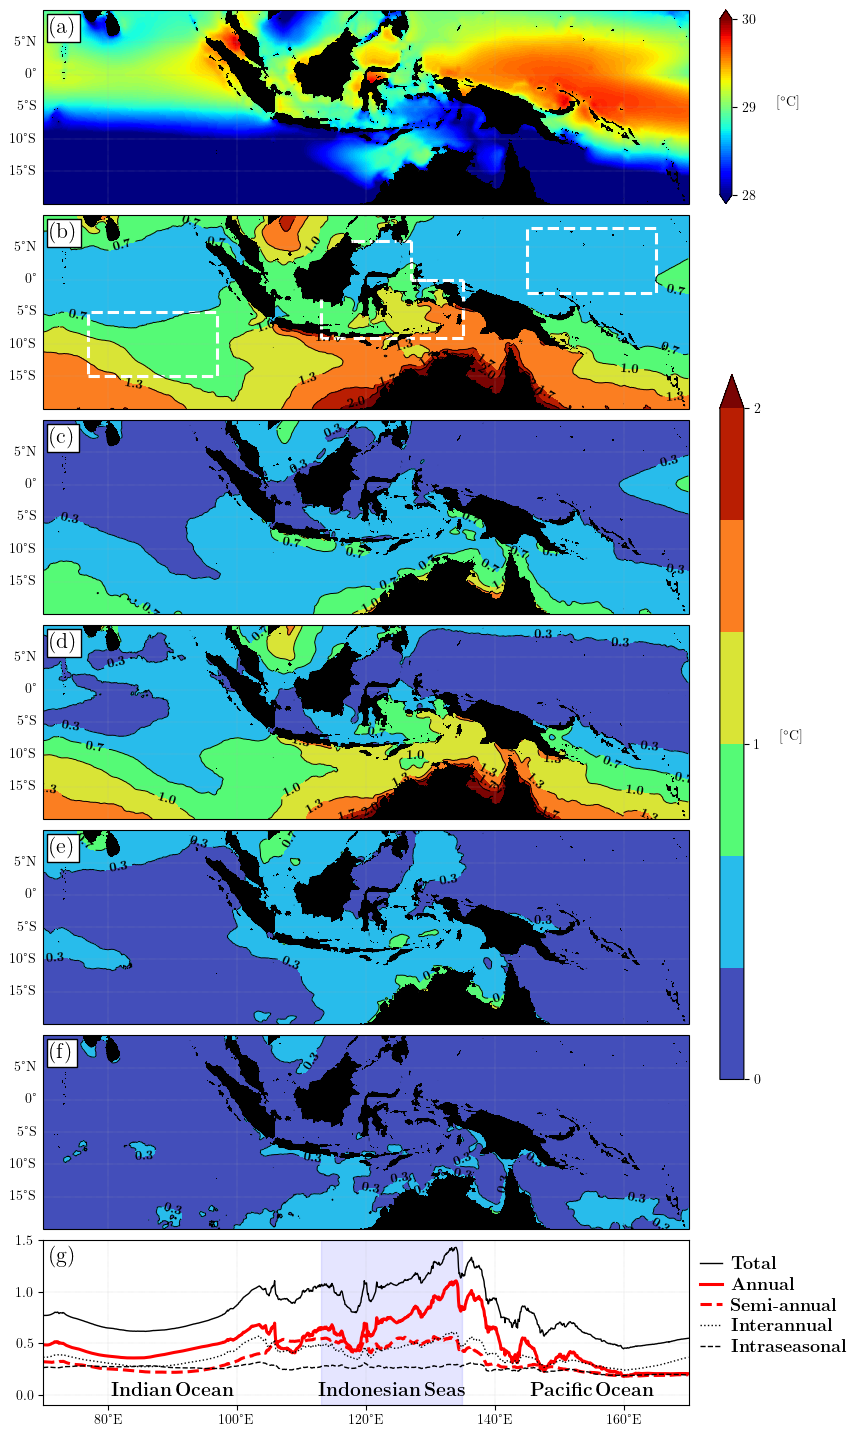

In [9]:
# ---------------------------
# Levels & titles
# ---------------------------
lev_total   = np.linspace(0, 2, 7)
tick_levels = np.linspace(0, 2, 3)
data_list = [mean_sst, total_sd, inter_sd, annual_sd, semiannual_sd, intra_sd]
titles_map = [
    r'(a)',
    r'(b)',
    r'(c)',
    r'(d)',
    r'(e)',
    r'(f)',
]

# ---------------------------
# FIGURE + GRID:
# ---------------------------
fig = plt.figure(figsize=(12, 15))

gs = fig.add_gridspec(
    nrows=7, ncols=1,
    height_ratios=[1, 1, 1, 1, 1, 1, 0.85],   # 6 maps + 1 line plot
    left=0.1, right=0.65,
    bottom=0.05, top=0.98,
    hspace=0.06
)

axs_map = [
    fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree(central_longitude=0))
    for i in range(6)
]
ax_line = fig.add_subplot(gs[6, 0])

# ---------------------------
# LAND GEOMETRY
# ---------------------------
land_feat  = cfeature.NaturalEarthFeature('physical', 'land', '10m')
land_union = unary_union(list(land_feat.geometries()))

def plot_box_edges_over_ocean(ax, polygon, **kws):
    """Plot straight edges of a rectangular polygon, only over ocean."""
    x, y = polygon.exterior.xy
    coords = list(zip(x, y))
    edges = [LineString([coords[i], coords[i+1]]) for i in range(len(coords)-1)]
    for edge in edges:
        ocean_part = edge.difference(land_union)
        geoms = getattr(ocean_part, "geoms", [ocean_part])
        for g in geoms:
            xg, yg = g.xy
            ax.plot(xg, yg, transform=ccrs.PlateCarree(), **kws)

c_mean = None   # mean SST (panel a)
c_var  = None   # variance maps (panels b–f)

# ---------------------------
# 6 MAP PANELS
# ---------------------------
for i, ax in enumerate(axs_map):
    data = data_list[i]

    # (a) mean SST
    if i == 0:
        vmin, vmax = 28, 30
        lev_sst = np.linspace(vmin, vmax, 81)

        c = ax.contourf(
            data.lon, data.lat, data.values,
            levels=lev_sst, cmap='jet', extend='both',
            transform=ccrs.PlateCarree()
        )
        c_mean = c
        cs = None

    # (b–f) variance maps
    else:
        c = ax.contourf(
            data.lon, data.lat, data.values,
            levels=lev_total, cmap='turbo', extend='max',
            transform=ccrs.PlateCarree()
        )
        cs = ax.contour(
            data.lon, data.lat, data.values,
            levels=lev_total, colors='k', linewidths=0.7, zorder=7,
            transform=ccrs.PlateCarree()
        )
        c_var = c

    if cs is not None:
        ax.clabel(
            cs, levels=lev_total,
            inline=True, fontsize=9,
            fmt=lambda x: f'\\textbf{{{x:.1f}}}'
        )
    if i == 1:
        plot_box_edges_over_ocean(
            ax, merged_poly,
            color="white", linestyle="--", linewidth=2.2, zorder=6
        )

        # IO: 77E–97E, 15S–5S
        io_x0, io_y0 = 77, -15
        io_w, io_h   = 20, 10
        # PO: 145E–165E, 2S–8N
        po_x0, po_y0 = 145, -2
        po_w, po_h   = 20, 10

        ax.add_patch(Rectangle((io_x0, io_y0), io_w, io_h,
                               linewidth=2.2, edgecolor='white', facecolor='none',
                               linestyle='--', zorder=6,
                               transform=ccrs.PlateCarree()))
        ax.add_patch(Rectangle((po_x0, po_y0), po_w, po_h,
                               linewidth=2.2, edgecolor='white', facecolor='none',
                               linestyle='--', zorder=6,
                               transform=ccrs.PlateCarree()))

    gl = ax.gridlines(
        draw_labels=True, dms=False,
        x_inline=False, y_inline=False, linestyle=':', lw=0.3
    )
    gl.top_labels = gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = False

    ax.set_facecolor('k')
    ax.add_feature(cfeature.LAND.with_scale("50m"),
                   facecolor="k", edgecolor="none", zorder=5)
    ax.set_extent([70, 170, -20, 10], crs=ccrs.PlateCarree())

    ax.text(
        0.01, 0.965, titles_map[i], transform=ax.transAxes,
        ha='left', va='top', fontsize=16, fontweight='bold', zorder=12,
        bbox=dict(facecolor='white', edgecolor='k', pad=2)
    )

# ---------------------------
# COLORBARS
# ---------------------------

# (a) mean cbar
pos = axs_map[0].get_position()
cax_mean = fig.add_axes([0.67, pos.y0, 0.01, pos.height])
cb_mean  = fig.colorbar(c_mean, cax=cax_mean, orientation='vertical', ticks=[28, 29, 30])
cb_mean.set_label(r'[$^\circ$C]', rotation=0)
cb_mean.ax.yaxis.set_label_coords(5.8, 0.56)

# (b–f) variance cbar
cax_var = fig.add_axes([0.67, 0.267, 0.02, 0.47])
cb_var  = fig.colorbar(c_var, cax=cax_var,
                       orientation='vertical', ticks=tick_levels)
cb_var.set_label(r'[$^\circ$C]', rotation=0)
cb_var.ax.yaxis.set_label_coords(3.0, 0.52)

# ---------------------------
# LINE PLOT PANEL
# ---------------------------

titles_line = [r'$\mathbf{Total}$', r'$\mathbf{Interannual}$', r'$\mathbf{Annual}$', r'$\mathbf{Semi\text{-}annual}$', r'$\mathbf{Intraseasonal}$']

data_total      = total_sd.sel(lat=slice(-10, 0)).mean('lat')
data_annual     = annual_sd.sel(lat=slice(-10, 0)).mean('lat')
data_semiannual = semiannual_sd.sel(lat=slice(-10, 0)).mean('lat')
data_intra      = intra_sd.sel(lat=slice(-10, 0)).mean('lat')
data_inter      = inter_sd.sel(lat=slice(-10, 0)).mean('lat')

data_total.plot(ax=ax_line,      color='k', label=titles_line[0], lw=1)
data_annual.plot(ax=ax_line,     color='r', label=titles_line[2], lw=2.2)
data_semiannual.plot(ax=ax_line, color='r', label=titles_line[3], lw=2.2, ls='--')
data_inter.plot(ax=ax_line,      color='k', ls=':', label=titles_line[1], lw=1)
data_intra.plot(ax=ax_line,      color='k', ls='--', label=titles_line[4], lw=1)

ax_line.set_xlim(70, 170)
ax_line.set_ylim(-0.1, 1.5)
ax_line.set_yticks([0, 0.5, 1.0, 1.5])
ax_line.set_xticks([80, 100, 120, 140, 160])
ax_line.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x)}°E")
)
ax_line.set_xlabel('')
ax_line.set_ylabel('')
ax_line.grid(ls=':', lw=0.3)

ymin, ymax = ax_line.get_ylim()
ax_line.fill_between(
    data_total.lon,
    ymax, ymin,
    where=(data_total.lon >= 113) & (data_total.lon <= 135),
    color='b', alpha=0.1, zorder=0
)

ax_line.text(124, -0.05, r'$\mathbf{Indonesian\,Seas}$',
             color='k', ha='center', va='bottom', fontsize=14, zorder=12)
ax_line.text(90, -0.05, r'$\mathbf{Indian\,Ocean}$',
             color='k', ha='center', va='bottom', fontsize=14, zorder=12)
ax_line.text(155, -0.05, r'$\mathbf{Pacific\,Ocean}$',
             color='k', ha='center', va='bottom', fontsize=14, zorder=12)
ax_line.text(
    0.01, 0.965, '(g)', transform=ax_line.transAxes,
    ha='left', va='top', fontsize=16, fontweight='bold', zorder=10)

ax_line.legend(
    frameon=False, ncols=1, loc='upper right',
    fontsize=13, handlelength=1.2, handletextpad=0.5,
    columnspacing=0.1, labelspacing=0.25, bbox_to_anchor=(1.27, 1)
)
fig.canvas.draw()
map_pos  = axs_map[0].get_position()
line_pos = ax_line.get_position()
ax_line.set_position([map_pos.x0, line_pos.y0, map_pos.width, line_pos.height])

plt.savefig('./figures/fig2.png',dpi=200, bbox_inches='tight', facecolor='white')

## Table 1:

In [10]:
# -----------------------------------------
# Band wise sd
# -----------------------------------------
inter_var_IS      = (inter_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()
season_var_IS     = (seasonal_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()
annual_var_IS     = (annual_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()
semiannual_var_IS = (semiannual_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()
intra_var_IS      = (intra_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()
total_var_IS      = (total_sd**2).where((mask1 == 0) | (mask2 == 0)).mean()

inter_var_IO      = (inter_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()
season_var_IO     = (seasonal_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()
annual_var_IO     = (annual_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()
semiannual_var_IO = (semiannual_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()
intra_var_IO      = (intra_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()
total_var_IO      = (total_sd**2).sel(lon=IO_lon_range, lat=IO_lat_range).mean()

inter_var_PO      = (inter_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()
season_var_PO     = (seasonal_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()
annual_var_PO     = (annual_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()
semiannual_var_PO = (semiannual_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()
intra_var_PO      = (intra_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()
total_var_PO      = (total_sd**2).sel(lon=PO_lon_range, lat=PO_lat_range).mean()

print('Indian Ocean:')
print(f"Interannual variability: {np.sqrt(inter_var_IO).values:.2f} °C")
print(f"Seasonal variability- ")
print(f"  Annual variability:    {np.sqrt(annual_var_IO).values:.2f} °C")
print(f"  Semi-annual var.:      {np.sqrt(semiannual_var_IO).values:.2f} °C")
print(f"Intraseasonal var.:      {np.sqrt(intra_var_IO).values:.2f} °C")
print(f"Total variability:       {np.sqrt(total_var_IO).values:.2f} °C")
print('----------------------------------------------')
print('Indonesian Seas:')
print(f"Interannual variability: {np.sqrt(inter_var_IS).values:.2f} °C")
print(f"Seasonal variability- ")
print(f"  Annual variability:    {np.sqrt(annual_var_IS).values:.2f} °C")
print(f"  Semi-annual var.:      {np.sqrt(semiannual_var_IS).values:.2f} °C")
print(f"Intraseasonal var.:      {np.sqrt(intra_var_IS).values:.2f} °C")
print(f"Total variability:       {np.sqrt(total_var_IS).values:.2f} °C")
print('----------------------------------------------')
print('Pacific Ocean:')
print(f"Interannual variability: {np.sqrt(inter_var_PO).values:.2f} °C")
print(f"Seasonal variability- ")
print(f"  Annual variability:    {np.sqrt(annual_var_PO).values:.2f} °C")
print(f"  Semi-annual var.:      {np.sqrt(semiannual_var_PO).values:.2f} °C")
print(f"Intraseasonal var.:      {np.sqrt(intra_var_PO).values:.2f} °C")
print(f"Total variability:       {np.sqrt(total_var_PO).values:.2f} °C")

Indian Ocean:
Interannual variability: 0.39 °C
Seasonal variability- 
  Annual variability:    0.65 °C
  Semi-annual var.:      0.28 °C
Intraseasonal var.:      0.29 °C
Total variability:       0.88 °C
----------------------------------------------
Indonesian Seas:
Interannual variability: 0.42 °C
Seasonal variability- 
  Annual variability:    0.66 °C
  Semi-annual var.:      0.47 °C
Intraseasonal var.:      0.26 °C
Total variability:       0.98 °C
----------------------------------------------
Pacific Ocean:
Interannual variability: 0.27 °C
Seasonal variability- 
  Annual variability:    0.19 °C
  Semi-annual var.:      0.17 °C
Intraseasonal var.:      0.18 °C
Total variability:       0.45 °C
